In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDRegressor, LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error
import joblib

# 1. Load Data
df = pd.read_csv('yield_df.csv')

In [2]:
# 1b. Data Cleaning & Feature Engineering (Rubric Requirement)
# Drop the useless index column ('Unnamed: 0') and categorical columns we don't need for our numeric regression
columns_to_drop = ['Unnamed: 0', 'Area', 'Item', 'Year']
df_cleaned = df.drop(columns=columns_to_drop)

In [3]:
# 2. Select the 3 numeric features from our cleaned dataset
selected_features = [
    'average_rain_fall_mm_per_year',
    'avg_temp',
    'pesticides_tonnes'
]

X = df_cleaned[selected_features]
y = df_cleaned['hg/ha_yield'] # Target: Predicting exact crop production

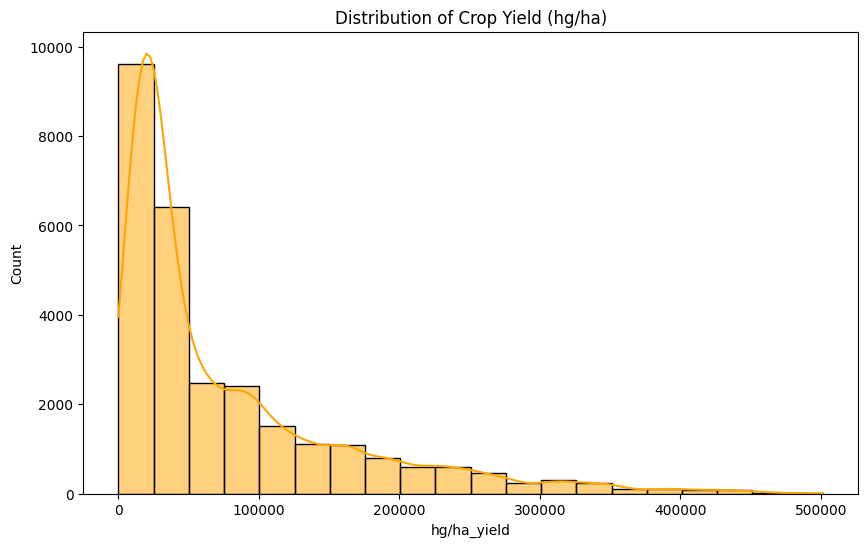

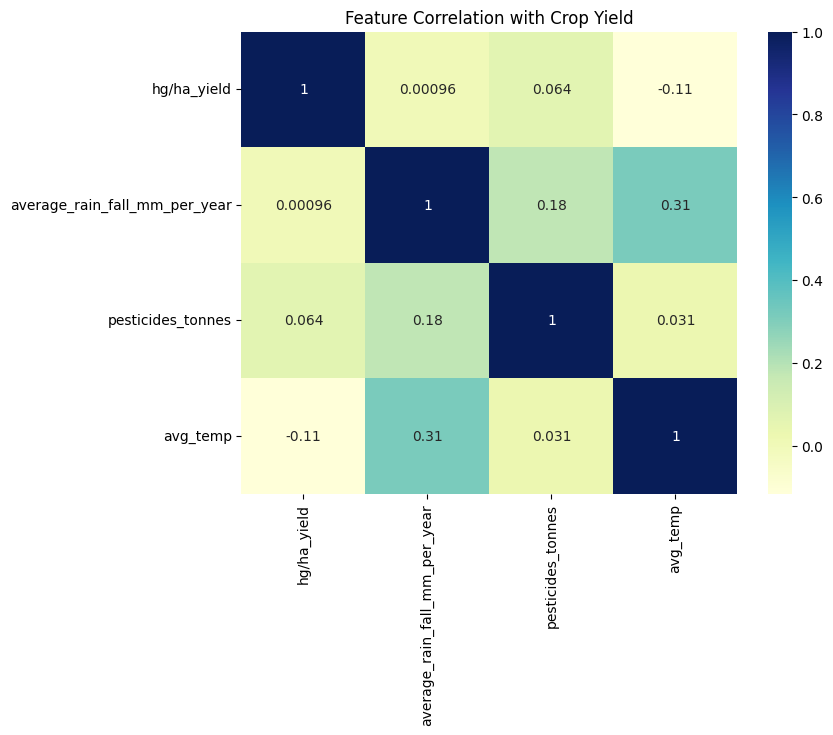

In [4]:
# 3. Visualizations (Required by Rubric)
plt.figure(figsize=(10, 6))
sns.histplot(y, bins=20, kde=True, color='orange')
plt.title('Distribution of Crop Yield (hg/ha)')
plt.show()

plt.figure(figsize=(8, 6))
sns.heatmap(df_cleaned.corr(), annot=True, cmap='YlGnBu')
plt.title('Feature Correlation with Crop Yield')
plt.show()

In [5]:
# 4. Split and Scale (THIS MUST COME BEFORE MODEL TRAINING)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Save the scaler for the API
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [6]:
# 5. Model Training & Comparison
models = {
    "Stochastic Gradient Descent": SGDRegressor(max_iter=1000, tol=1e-3, random_state=42),
    "Standard Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Decision Tree": DecisionTreeRegressor(random_state=42)
}

best_model = None
lowest_mse = float('inf')

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    mse = mean_squared_error(y_test, preds)
    print(f"{name} MSE: {mse:.4f}")
    if mse < lowest_mse:
        lowest_mse = mse
        best_model = model

# Save the best model
joblib.dump(best_model, 'best_model.pkl')
print(f"\nBest Model Saved: {best_model}")

Stochastic Gradient Descent MSE: 7099806220.8216
Standard Linear Regression MSE: 7098843519.7891
Random Forest MSE: 8720106522.9452
Decision Tree MSE: 9149870878.0881

Best Model Saved: LinearRegression()


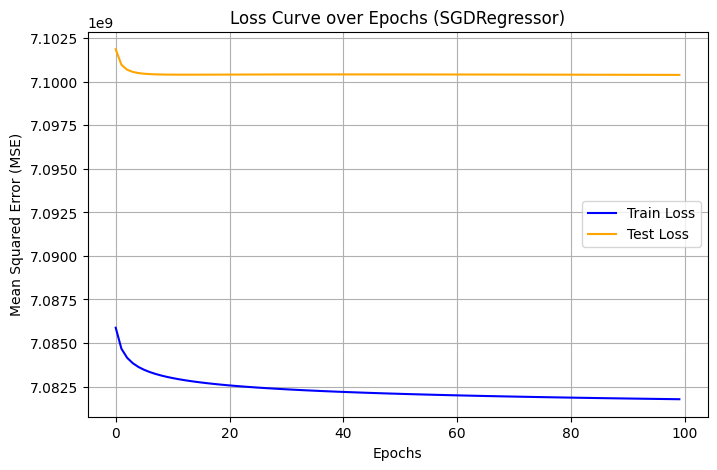

In [7]:
# 5b. Plot Loss Curve for Test and Train Data (Rubric Requirement)
sgd_model = SGDRegressor(random_state=42)
train_losses = []
test_losses = []

epochs = 100
for epoch in range(epochs):
    # Fit one epoch at a time
    sgd_model.partial_fit(X_train_scaled, y_train)

    # Calculate MSE for both Train and Test sets
    train_pred = sgd_model.predict(X_train_scaled)
    test_pred = sgd_model.predict(X_test_scaled)

    train_losses.append(mean_squared_error(y_train, train_pred))
    test_losses.append(mean_squared_error(y_test, test_pred))

# Plotting the Loss Curve
plt.figure(figsize=(8, 5))
plt.plot(range(epochs), train_losses, label='Train Loss', color='blue')
plt.plot(range(epochs), test_losses, label='Test Loss', color='orange')
plt.title('Loss Curve over Epochs (SGDRegressor)')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error (MSE)')
plt.legend()
plt.grid(True)
plt.show()

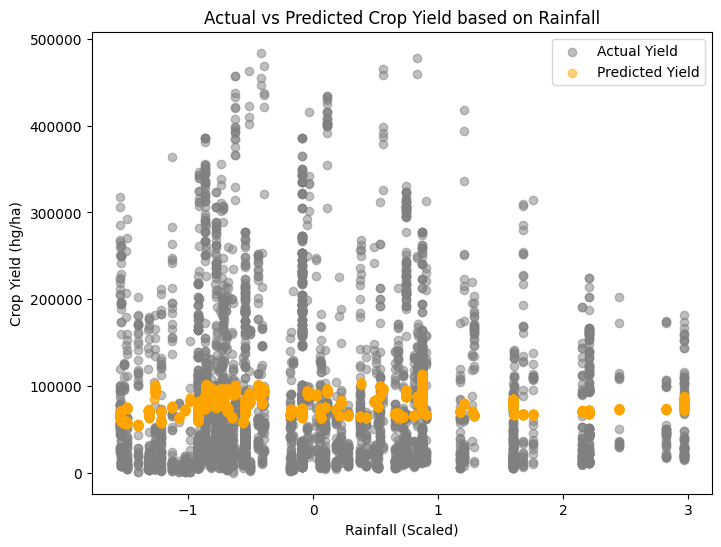

In [8]:
# 6. Scatter Plot of Before & After (Rubric Requirement)
feature_idx = 0 # Plotting against Rainfall
plt.figure(figsize=(8, 6))
plt.scatter(X_test_scaled[:, feature_idx], y_test, color='gray', label='Actual Yield', alpha=0.5)
plt.scatter(X_test_scaled[:, feature_idx], best_model.predict(X_test_scaled), color='orange', label='Predicted Yield', alpha=0.5)
plt.title('Actual vs Predicted Crop Yield based on Rainfall')
plt.xlabel('Rainfall (Scaled)')
plt.ylabel('Crop Yield (hg/ha)')
plt.legend()
plt.show()

In [9]:
# 7. Single Data Point Prediction (Rubric Requirement)
single_data = X_test_scaled[0].reshape(1, -1)
actual = y_test.iloc[0]
predicted = best_model.predict(single_data)[0]

print("\n--- Single Farm Prediction ---")
print(f"Actual Yield: {actual} hg/ha | Predicted Yield: {predicted:.2f} hg/ha")


--- Single Farm Prediction ---
Actual Yield: 69220 hg/ha | Predicted Yield: 80809.53 hg/ha
